# Quantization Aware Training + Knowledge Distillation

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from torch.utils.data import DataLoader
from typing import Callable

from src.utils import load_data
from src.Quantization.utils.post_training_quantization import quantize_model
from src.Quantization.utils.preprocessing import load_kd_model
from src.utils import compute_loss_and_predictions, calculate_metrics, plot_train_val_curve
from src.utils import test_inference
from src.utils import model_size, measure_inference_performance, calculate_speedup, measure_memory_usage

In [2]:
# Specify random seed for repeatable results
_ = torch.manual_seed(191009)

### Helper Functions

In [3]:
def load_quantized_model(model_path: str, device: torch.device = torch.device("cpu")) -> torch.jit.ScriptModule:
    """
    Loads a quantized TorchScript model from the specified file.

    Parameters:
        model_path (str): Path to the saved TorchScript model (.pt file).
        device (torch.device): The device on which to load the model. Defaults to CPU.
    
    Returns:
        torch.jit.ScriptModule: The loaded quantized model.
    """
    # Load the TorchScript model from disk, mapping it to the specified device.
    model = torch.jit.load(model_path, map_location=device)
    # Set the model to evaluation mode (important for inference)
    model.eval()
    return model

def compute_distillation_loss(teacher_logits: torch.Tensor, student_logits: torch.Tensor, T: float) -> torch.Tensor:
    """
    Computes the distillation loss using KL divergence with softened logits.

    Parameters:
        teacher_logits (torch.Tensor): Logits from the teacher model.
        student_logits (torch.Tensor): Logits from the student model.
        T (float): Temperature to soften the logits.

    Returns:
        torch.Tensor: The computed distillation loss.
    """
    soft_loss = F.kl_div(
        F.log_softmax(student_logits / T, dim=1),
        F.softmax(teacher_logits / T, dim=1),
        reduction='batchmean'
    ) * (T ** 2)
    return soft_loss

In [4]:
# model = torch.ao.quantization.convert(model.eval(), inplace=False)
# print_model_size(model)

# torch.jit.save(torch.jit.script(model), "../../mobilenetv2_quantized.pt")

# model_test = load_quantized_model("../../mobilenetv2_quantized.pt")

In [5]:
def train_knowledge_distillation(
    teacher: nn.Module,
    student: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int,
    criterion: Callable[[torch.Tensor, torch.Tensor], torch.Tensor],
    optimizer: torch.optim.Optimizer,
    T: float,
    soft_target_loss_weight: float,
    ce_loss_weight: float,
    device: torch.device
) -> None:
    """
    Trains the student model using knowledge distillation from the teacher model.
    The loss is a weighted sum of the KL divergence (distillation loss) and the standard cross entropy loss.
    Validation is performed at the end of each epoch.
    
    Parameters:
        teacher (nn.Module): The pre-trained teacher model.
        student (nn.Module): The student model to be trained.
        train_loader (DataLoader): DataLoader for the training dataset.
        val_loader (DataLoader): DataLoader for the validation dataset.
        epochs (int): Number of training epochs.
        criterion (Callable): Loss function for the true label loss (e.g., nn.CrossEntropyLoss).
        optimizer (torch.optim.Optimizer): Optimizer for updating the student model parameters.
        T (float): Temperature for softening the logits.
        soft_target_loss_weight (float): Weight for the distillation (soft targets) loss.
        ce_loss_weight (float): Weight for the cross entropy loss on true labels.
        device (torch.device): Device to perform training on.
    """
    loss_dict = {'train': [], 'val': []}
    # Set teacher to evaluation mode (its parameters won't be updated)
    teacher.eval()
    
    for epoch in range(epochs):
        for phase in ['train', 'val']:
            is_train = phase == 'train'
            student.train() if is_train else student.eval()
            data_loader = train_loader if is_train else val_loader

            running_loss = 0.0
            total_samples  = 0.0
            predictions, ground_truths, probabilities = [], [], []

            with tqdm(total=len(data_loader), desc=f"{phase.capitalize()} Epoch {epoch + 1}/{epochs}") as pbar:
                for inputs, labels in data_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    
                    # Zero gradients only during training
                    if is_train:
                        optimizer.zero_grad()
                    
                    # Teacher forward pass without gradient computation.
                    with torch.no_grad():
                        teacher = teacher.to(device)
                        teacher_logits = teacher(inputs)
                    
                    # Enable gradients only in training phase
                    with torch.set_grad_enabled(is_train):
                        student = student.to(device)
                        # Student forward pass.
                        student_logits = student(inputs)

                        # Compute soft targets loss using KL divergence.
                        # Using 'batchmean' ensures the loss is averaged over the batch.
                        soft_loss = compute_distillation_loss(teacher_logits=teacher_logits, student_logits=student_logits, T=T)

                        # Compute the true label loss and obtain predictions/probabilities
                        label_loss, probs, preds = compute_loss_and_predictions(student_logits, labels, criterion)
                        
                        # Compute weighted combination of the distillation and cross entropy losses
                        loss = soft_target_loss_weight * soft_loss + ce_loss_weight * label_loss

                        # Backward pass and optimizer step in training phase
                        if is_train:
                            loss.backward()
                            optimizer.step()
                    
                    # Update running loss and sample count
                    batch_size = inputs.size(0)
                    running_loss += loss.item() * batch_size
                    total_samples += batch_size

                    # Accumulate predictions and ground truths for metrics
                    ground_truths.extend(labels.cpu().detach().numpy())
                    predictions.extend(preds.cpu().detach().numpy())
                    probabilities.extend(probs.cpu().detach().numpy())
                    
                    # Update progress bar with average loss so far
                    pbar.set_postfix(loss=f"{running_loss / total_samples:.4f}")
                    pbar.update(1)
                
            # Compute aggregated metrics after epoch
            epoch_loss = running_loss / total_samples
            loss_dict[phase].append(epoch_loss)
            y_true = np.array(ground_truths)
            y_pred = np.array(predictions)
            y_proba = np.array(probabilities) if probabilities else None

            # Calculate metrics
            metrics = calculate_metrics(y_true, y_pred, y_proba)

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f}")
            print(f"{phase.capitalize()} Metrics: " + ", ".join([f"{key}: {value:.4g}" for key, value in metrics.items()]))

    return student, loss_dict

### Hyperparameters

/home/jacob-delgado/anaconda3/envs/ECG/lib/python3.12/site-packages/torch/ao/quantization/observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(
/home/jacob-delgado/Documents/model-compression/src/Quantization/utils/preprocessing.py:237: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the

Train Loss: 0.8817
Train Metrics: Accuracy: 0.6779, Recall: 0.4856, Precision: 0.5873, F1-Score: 0.507, AUC-Score: 0.9386


Val Epoch 1/1: 100%|██████████| 115/115 [00:20<00:00,  5.74it/s, loss=0.6904]
/home/jacob-delgado/anaconda3/envs/ECG/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Val Loss: 0.6904
Val Metrics: Accuracy: 0.7402, Recall: 0.5721, Precision: 0.7403, F1-Score: 0.5976, AUC-Score: 0.9636


Inference Progress: 100%|██████████| 115/115 [00:18<00:00,  6.31it/s]
/home/jacob-delgado/anaconda3/envs/ECG/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Metrics Results:
Accuracy: 0.7169
Recall: 0.5502
Precision: 0.6371
F1-Score: 0.5707
AUC-Score: 0.9580
Teacher Inference Time: 0.000028 sec, Throughput: 35554.46 samples/sec
Student Inference Time: 0.000218 sec, Throughput: 4590.11 samples/sec
Speedups: {'time_speedup': 0.12910078693765115, 'throughput_speedup': 0.12910078693765115}
Teacher Memory Usage: 417.791015625
Student Memory Usage: 584.17333984375


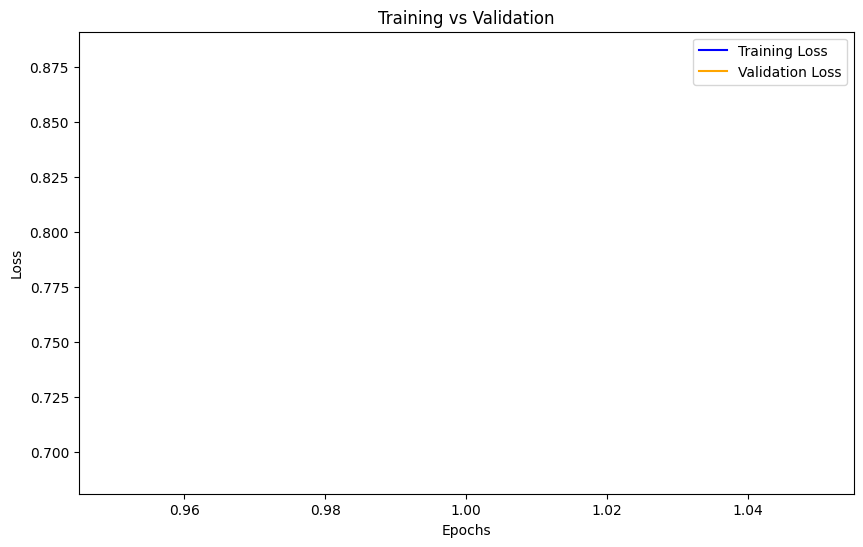

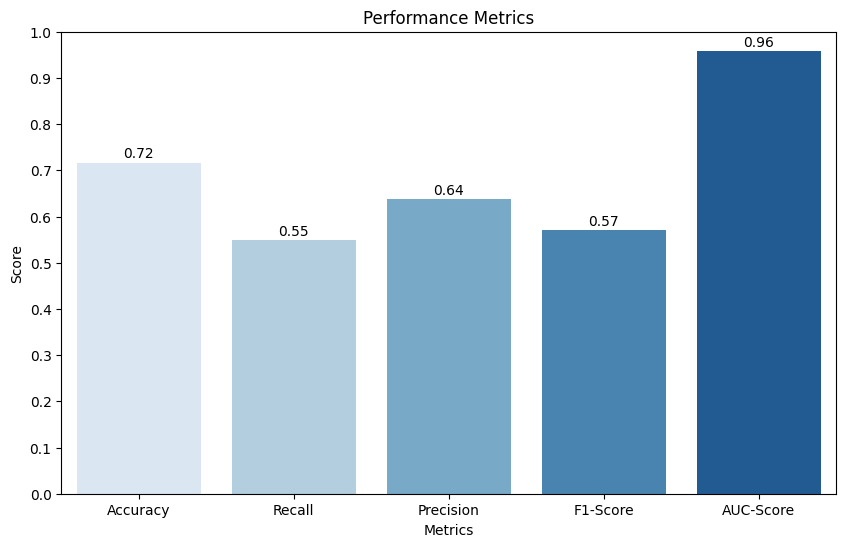

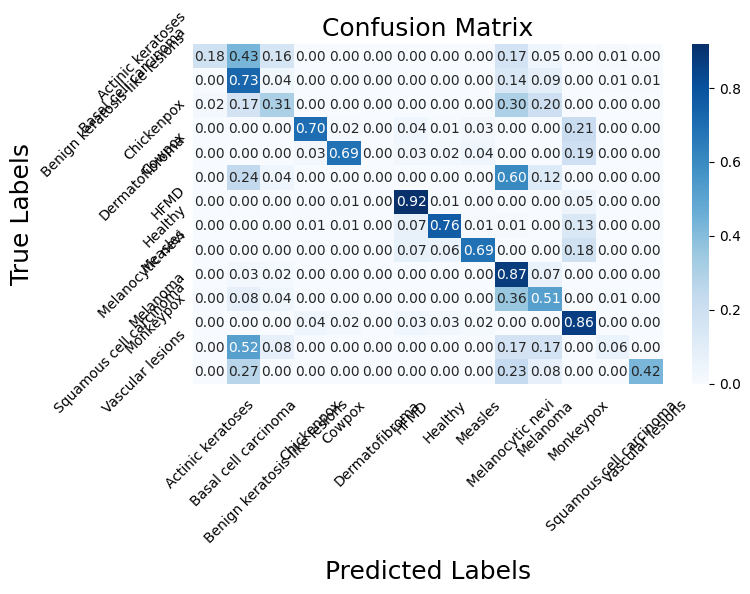

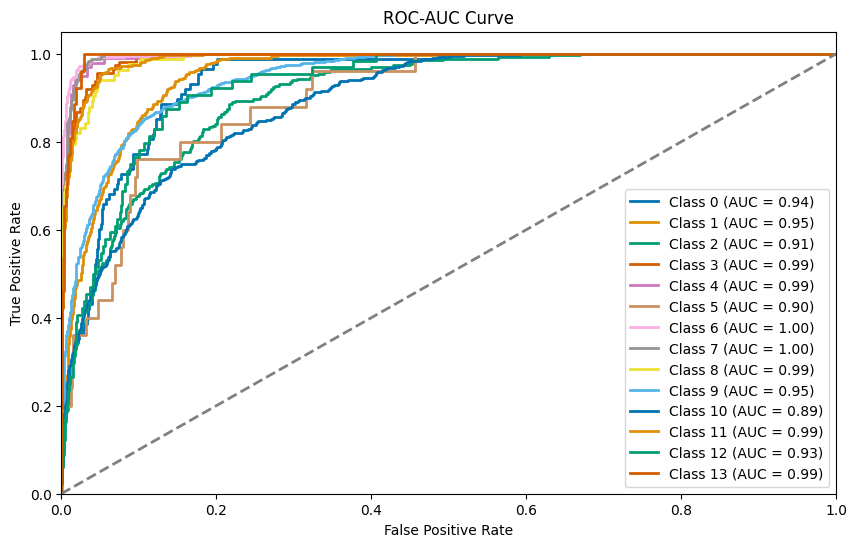

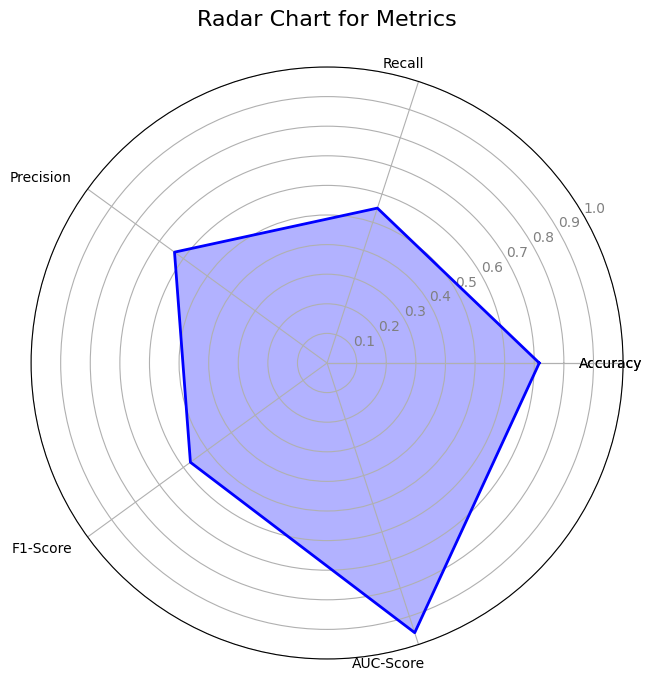

In [ ]:
dataset = "SkinCancer"
batch_size = 32
learning_rate = 0.001
save_dir = f"models/{dataset}/Quantized"
os.makedirs(save_dir, exist_ok=True)

dataloaders = load_data(dataset=dataset, batch_size=batch_size)
num_classes = len(dataloaders["train"].dataset.classes)

model_weights_path = 'models/SkinCancer/mobilenet_v2_best_model.pth'  # Update with your saved model weights

# Device configuration - quantization is often done on CPU.
device = torch.device("cuda")

# Load the student model (quantization-ready version by passing None for weights_path).
student_model = load_kd_model("mobilenet_v2", None, num_classes)
student_model.train()
student_model.fuse_model(is_qat=True)
student_model.qconfig = torch.ao.quantization.get_default_qat_qconfig('x86')
torch.ao.quantization.prepare_qat(student_model, inplace=True)

# Load the teacher model (with fine-tuned weights).
teacher_model = load_kd_model("mobilenet_v2", model_weights_path, num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(student_model.parameters(), lr=learning_rate)

# Train the student model using knowledge distillation.
student, loss_dict = train_knowledge_distillation(
                        teacher=teacher_model, 
                        student=student_model, 
                        train_loader=dataloaders['train'],
                        val_loader=dataloaders['val'],  
                        epochs=1, 
                        criterion=criterion,
                        optimizer=optimizer,
                        T=2, 
                        soft_target_loss_weight=0.25, 
                        ce_loss_weight=0.75, 
                        device=device
                    )

torch.save(student.state_dict(), os.path.join(save_dir, "quantized_model.pth"))
plot_train_val_curve(loss_dict, save_path=os.path.join(save_dir, "loss_curve.png"))

# Evaluate teacher and student models.
# teacher_metrics = test_inference(teacher_model, test_loader=dataloaders['test'], criterion=criterion, device=device, save_dir=save_dir)
teacher_metrics = test_inference(teacher_model, test_loader=dataloaders['test'], device=device, save_dir=save_dir)

# Measure model sizes.
script_size, pth_size = model_size(student)

# Measure inference performance.
avg_time_teacher, throughput_teacher = measure_inference_performance(teacher_model, data_loader=dataloaders['test'], device=device)
avg_time_student, throughput_student = measure_inference_performance(student, data_loader=dataloaders['test'], device=device)
speedup = calculate_speedup(avg_time_teacher, throughput_teacher, avg_time_student, throughput_student)

# Measure memory usage.
memory_usage_teacher = measure_memory_usage(teacher_model, dataloaders['test'], device)
memory_usage_student = measure_memory_usage(student, dataloaders['test'], device)

print(f"Teacher Inference Time: {avg_time_teacher:.6f} sec, Throughput: {throughput_teacher:.2f} samples/sec")
print(f"Student Inference Time: {avg_time_student:.6f} sec, Throughput: {throughput_student:.2f} samples/sec")
print("Speedups:", speedup)
print("Teacher Memory Usage:", memory_usage_teacher)
print("Student Memory Usage:", memory_usage_student)